In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
device

'cuda'

In [2]:
# Create dataset
X, y = datasets.make_regression(
    n_samples=1000, n_features=10, noise=10, random_state=4)
y = y.reshape(-1, 1)

In [3]:
X[0:1], y[0:1]

(array([[-0.28752778, -0.28946792, -0.39001048,  0.63694009, -1.72748699,
          0.86361724,  1.40292408, -0.44358291,  1.12684153, -0.40738215]]),
 array([[-47.21146934]]))

In [4]:
# Normalize the data
X_scaler = MinMaxScaler()
X_scaled = X_scaler.fit_transform(X)
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y)

In [5]:
X_scaled[0:1], y_scaled[0:1]

(array([[0.45767336, 0.46888444, 0.41091171, 0.55134305, 0.19341815,
         0.64598204, 0.74519062, 0.39541084, 0.63452014, 0.44218126]]),
 array([[0.46615362]]))

In [6]:
X_scaled.shape, y_scaled.shape

((1000, 10), (1000, 1))

In [7]:
# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.33, random_state=42)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((670, 10), (330, 10), (670, 1), (330, 1))

In [9]:
class Data(Dataset):
  '''Dataset Class to store the samples and their corresponding labels, 
  and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.
  '''

  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:

    # need to convert float64 to float32 else 
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X.astype(np.float32)).to(device)
    self.y = torch.from_numpy(y.astype(np.float32)).to(device)
    self.len = self.X.shape[0]
  
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]

  def __len__(self) -> int:
    return self.len

In [10]:
# Generate the training dataset
traindata = Data(X_train, y_train)

In [11]:
testdata = Data(X_test, y_test)

In [12]:
batch_size = 64
# tells the data loader instance how many sub-processes to use for data loading
# if the num_worker is zero (default) the GPU has to weight for CPU to load data
# Theoretically, greater the num_workers, 
# more efficiently the CPU load data and less the GPU has to wait
# num_workers = 32

# Load the training data into data loader with the 
# respective batch_size and num_workers
trainloader = DataLoader(traindata, batch_size=batch_size, 
                         shuffle=True)

train_acc_loader = DataLoader(traindata, batch_size=len(traindata))

testloader = DataLoader(testdata, batch_size=len(testdata))

In [64]:
class LinearRegression(nn.Module):
    '''Linear Regression Model
    '''

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        '''The network has 4 layers
             - input layer
             - hidden layer
             - hidden layer
             - output layer
        '''
        super(LinearRegression, self).__init__()
        self.act = nn.ReLU()
        self.input_to_hidden = nn.Linear(input_dim, hidden_dim)
        self.hidden_layer_1 = nn.Linear(hidden_dim, hidden_dim)
        self.hidden_layer_2 = nn.Linear(hidden_dim, hidden_dim)
        self.hidden_to_output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # no activation and no softmax at the end
        x = self.act(self.input_to_hidden(x))
        x = self.act(self.hidden_layer_1(x))
        x = self.act(self.hidden_layer_2(x))
        x = self.hidden_to_output(x)
        return x

In [65]:
# number of features (len of X cols)
input_dim = X_train.shape[1]
# number of hidden layers
hidden_layers = 50
# output dimension is 1 because of linear regression
output_dim = y_train.shape[1]
# initiate the linear regression model
model = LinearRegression(input_dim, hidden_layers, output_dim).to(device)
print(model)

LinearRegression(
  (act): ReLU()
  (input_to_hidden): Linear(in_features=10, out_features=50, bias=True)
  (hidden_layer_1): Linear(in_features=50, out_features=50, bias=True)
  (hidden_layer_2): Linear(in_features=50, out_features=50, bias=True)
  (hidden_to_output): Linear(in_features=50, out_features=1, bias=True)
)


In [66]:
summary(model, (64,10))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 64, 50]             550
              ReLU-2               [-1, 64, 50]               0
            Linear-3               [-1, 64, 50]           2,550
              ReLU-4               [-1, 64, 50]               0
            Linear-5               [-1, 64, 50]           2,550
              ReLU-6               [-1, 64, 50]               0
            Linear-7                [-1, 64, 1]              51
Total params: 5,701
Trainable params: 5,701
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.02
Estimated Total Size (MB): 0.17
----------------------------------------------------------------


In [67]:
# criterion to computes the loss between input and target
criterion = nn.MSELoss()
# optimizer that will be used to update weights and biases
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [68]:
trainingloss = []
testloss = []

In [69]:
model.eval()
X_acc_train, y_acc_train = next(iter(train_acc_loader))
X_acc_test, y_acc_test = next(iter(testloader))

In [78]:
epochs = 100
for epoch in tqdm(range(epochs)):
    model.train()
    for (inputs, labels) in trainloader:
        # inputs, labels = data

        # forward propagation
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # set optimizer to zero grad 
        # to remove previous epoch gradients
        optimizer.zero_grad()

        # backward propagation
        loss.backward()

        # optimize
        optimizer.step()
    model.eval()
    # X_acc_train, y_acc_train = next(iter(train_acc_loader))
    trainingloss.append(criterion(model(X_acc_train), y_acc_train).item())
    # X_acc_test, y_acc_test = next(iter(testloader))
    testloss.append(criterion(model(X_acc_test), y_acc_test).item())  

100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 71.32it/s]


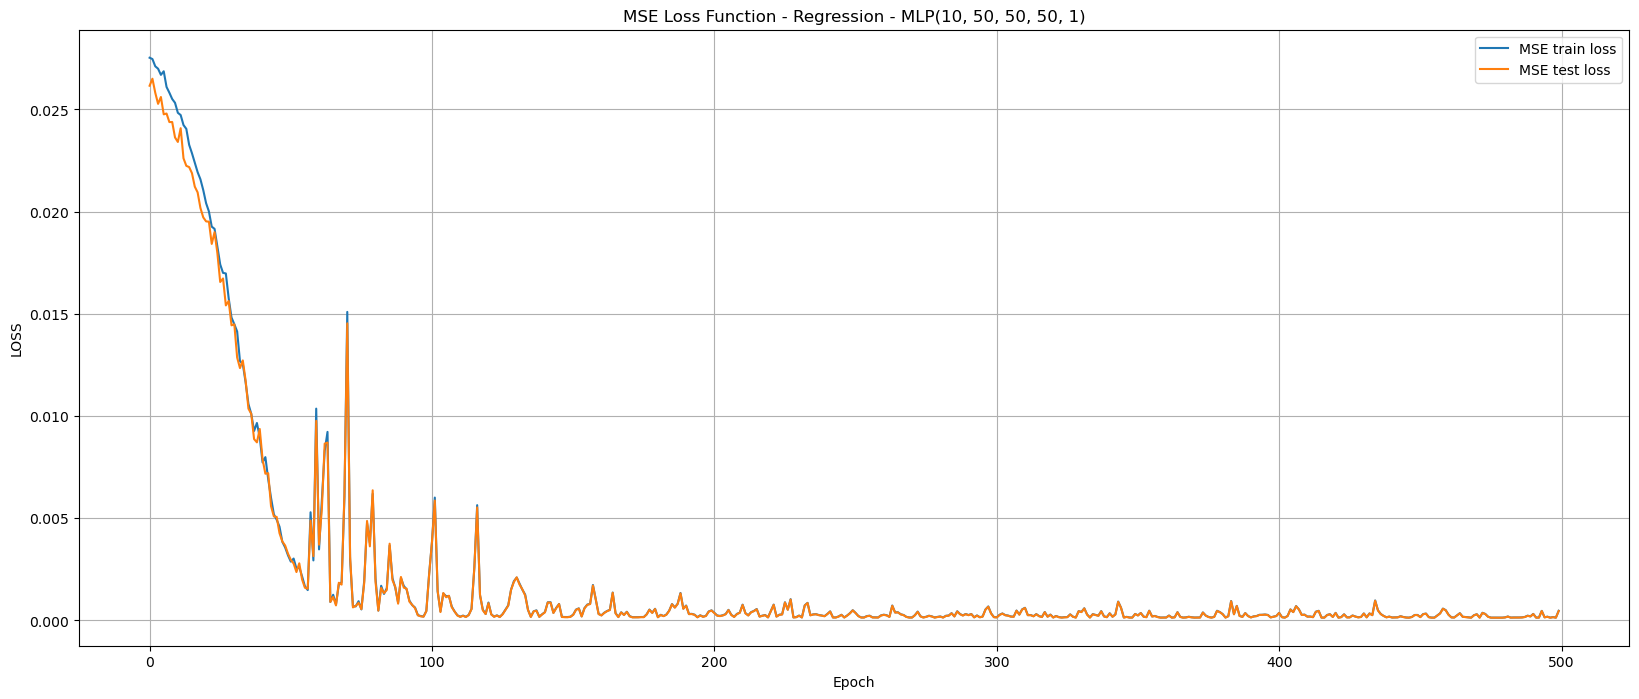

In [79]:
fig, ax = plt.subplots(figsize=(20,8))


ax.plot(trainingloss, label='MSE train loss')
ax.plot(testloss, label='MSE test loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('LOSS')
ax.legend()
ax.grid()
ax.set_title("MSE Loss Function - Regression - MLP(10, 50, 50, 50, 1)")

plt.show()

In [80]:
for x in model.parameters():
    x.requires_grad = False

In [81]:
entrada = torch.rand(10, requires_grad = True).to(device)

In [82]:
entrada

tensor([0.5126, 0.9748, 0.1426, 0.9525, 0.2696, 0.1836, 0.8585, 0.4011, 0.2734,
        0.7251], device='cuda:0', grad_fn=<ToCopyBackward0>)

In [83]:
epsilon = 0.0001
iterations = 1000

In [92]:
for t in tqdm(range(iterations)):
    entrada.retain_grad()
    loss = criterion(model(entrada), torch.tensor([0.5], dtype=torch.float32).to(device))
    loss.backward()
    
    entrada -= 0.00001*entrada.grad
    # print(type(salida.item()))
    if torch.abs(model(entrada)- 0.5).item() < epsilon:
        print(model(entrada))
        break;

 26%|██████████▏                             | 256/1000 [00:03<00:11, 64.32it/s]

tensor([0.5001], device='cuda:0', grad_fn=<ViewBackward0>)


In [93]:
model(entrada)

tensor([0.5001], device='cuda:0', grad_fn=<ViewBackward0>)

In [94]:
entrada

tensor([-1.2214,  2.7617, -0.4361,  1.2188, -3.1011, -0.0712, -1.3287, -1.6563,
        -6.3462,  2.4959], device='cuda:0', grad_fn=<SubBackward0>)

In [95]:
entrada.grad

tensor([ 4.3128, 13.9945, -0.1903, 29.8191, 42.8383, -2.4243, 15.9253, 22.5735,
         6.8446, 28.3227], device='cuda:0')